# CBADVAI MCO Project

**Members:**
- Borromeo, Ed Bennett
- Dompor, Rovick
- Fuentes, Matthew

Reusable classes and functions live in `src/models/` and are imported below. `RTA_EDSA_2007-2016.csv` is located automatically from the `dataset/` folder — no manual setup needed.

# Section 1: Dataset Description

The `RTA_EDSA_2007-2016` dataset contains officially recorded road traffic accidents along Epifanio de los Santos Avenue (EDSA), Metro Manila, from 2007 through 2016. Each row represents an accident report, while each column describes an aspect of the incident. The CSV contains 22,072 observations and 26 variables.

### Collection Method

Luz and Blanco published the dataset through Mendeley Data. They obtained the records from the Metro Manila Development Authority through the Data for Road Incident Visualization, Evaluation, and Reporting (DRIVER) System. The stated primary sources were MMDA Metrobase, the MMDA Road Safety Unit, and the Philippine National Police Traffic Management Group. The original `.xls` file was converted to `.csv` for this project.

### Description of All Variables

| Variable | Meaning |
|---|---|
| `LOCATION_TEXT` | Text description of the accident location |
| `ROAD` | Road on which the accident occurred |
| `WEATHER` | Recorded weather condition |
| `LIGHT` | Recorded lighting condition |
| `DESC` | Additional incident description |
| `REPORTING_AGENCY` | Agency that reported the incident |
| `MAIN_CAUSE` | Cause assessed by the reporting agent |
| `INCIDENTDETAILS_ID` | Accident-record identifier |
| `DATE_UTC`, `TIME_UTC` | Accident date and time in UTC |
| `ADDRESS` | Descriptive street address |
| `killed_driver`, `killed_passenger`, `killed_pedestrian` | Death counts by road-user category |
| `injured_driver`, `injured_passenger`, `injured_pedestrian` | Injury counts by road-user category |
| `killed_uncategorized`, `injured_uncategorized` | Death and injury counts without a road-user category |
| `killed_total`, `injured_total` | Total recorded deaths and injuries |
| `DATETIME_PST` | Local Philippine accident date and time |
| `SEVERITY` | Property, Injury, or Fatal classification |
| `X` | Longitude of the recorded location |
| `Y` | Latitude of the recorded location |
| `COLLISION_TYPE` | Reported collision configuration |

This study uses `DATETIME_PST`, `SEVERITY`, `X`, `Y`, and `COLLISION_TYPE`. Raw coordinates replace `ADDRESS` because Phase 2 will examine spatial patterns without predefined geographic sectors.

# Section 2: Data Pipeline

This section will go over the methods, functions, and structure of the dataset in preparation for the learning model. 

### 2.1 List of Libraries / Modules

The pipeline and model will make use of the following Libraries, for ploting, dataframe use, mathematical functions, and useful functions related to dataset preparation.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

sys.path.insert(0, str(Path.cwd().parent))

from models.data_processing import (
    DataPipeline,
    STUDY_VARIABLES,
    VALID_SEVERITIES,
    UNKNOWN_COLLISION_TYPE,
    COLLISION_TYPES,
    X_MIN,
    X_MAX,
    Y_MIN,
    Y_MAX,
)
from models.logistic_regression import MultinomialLogisticRegression
from models.mlp import MLP
from models.training import run_kfold_valid, train_and_evaluate_final_model
from models.evaluation import summarize_metrics
from models.plotting import PlotGeneration

np.random.seed(42)  # reproducible weight initialization across model runs

### 2.2 Constants, and Learning Targets

The following are the constants used for Dataset Pipeline.

The chosen study variables will be used to determine the kind of Collision_Type present in the Road Traffic Accident. These were choosen for their association with the Target Variable.

The constants `VALID_SEVERITIES` and `COLLISION_TYPES` are used to confirm and verify the variable values that will be present for their specific variable. This prevents outside variables and ensures the validity of the dataset.

The constants `X_MIN` and `X_MAX` & `Y_MIN` and `Y_MAX`, are used to verify the values present in the variables `X` and `Y`, as to make sure they are within the actual bounds of EDSA. Any rows that exceed either of these boundaries will be removed.


The constant `UNKNOWN_COLLISION_TYPE` is used to remove rows that have no confirmed `COLLISION_TYPE`, which in the dataset is set to "No Collision Stated" on Default.

### 2.3 Data Processing

This code block covers the DataPipeline Class to help process the dataset for the models.

It performs:
- Finding the Dataset and Loading the Dataset for processing.
- Use `STUDY_VARIABLES` to immediatly reduce the dataset to the desired columns.
- Checking for duplicates.
- Use `VALID_SEVERITIES` & `COLLISION_TYPES` to verify correct values for the corresponding 
- Filtering for the valid types to be used.
- Parsing `DATETIME_PST` to derive the variable `HOUR` to be used in the model.
- Convert `HOUR` to sine `HOUR_SIN` and cosine `HOUR_COS` to retain the Cyclical nature.
- One-hot Encoding for the categorial variables.

### 2.4 Dataset Loading and Processing

We will now initialize the `DataPipeline` object and load the dataset in preparation for cleaning.

Let's also check its info to compare it for after processing.

In [5]:
dp = DataPipeline()
dataset_path = dp.find_dataset_path()
RTA_df = dp.load_dataset(dataset_path)

RTA_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22072 entries, 0 to 22071
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   LOCATION_TEXT          304 non-null    object 
 1   ROAD                   22072 non-null  object 
 2   WEATHER                304 non-null    object 
 3   LIGHT                  304 non-null    object 
 4   DESC                   22072 non-null  object 
 5   REPORTING_AGENCY       22072 non-null  object 
 6   MAIN_CAUSE             304 non-null    object 
 7   INCIDENTDETAILS_ID     22072 non-null  object 
 8   DATE_UTC               22072 non-null  object 
 9   TIME_UTC               22072 non-null  object 
 10  ADDRESS                21768 non-null  object 
 11  killed_driver          22072 non-null  int64  
 12  killed_passenger       22072 non-null  int64  
 13  killed_pedestrian      22072 non-null  int64  
 14  injured_driver         22072 non-null  int64  
 15  in

Let's start with selecting the required variables and auditing them. 

In [6]:
RTA_df = dp.select_study_variables(RTA_df)
audit = dp.audit_study_data(RTA_df)

print(f"Selected shape: ({audit['rows']}, {audit['columns']})")
print("\nData types:")
print(audit["dtypes"])
print("\nMissing values:")
print(audit["missing"])
print("\nSeverity values:", audit["severity_values"])
print("Collision-type values:", audit["collision_type_values"])
print("Selected-field duplicate rows:", audit["exact_duplicate_rows"])

Selected shape: (22072, 5)

Data types:
DATETIME_PST       object
SEVERITY           object
X                 float64
Y                 float64
COLLISION_TYPE     object
dtype: object

Missing values:
DATETIME_PST      0
SEVERITY          0
X                 0
Y                 0
COLLISION_TYPE    0
dtype: int64

Severity values: ['Fatal', 'Injury', 'Property']
Collision-type values: ['Angle Impact', 'Head-On', 'Hit Object', 'Multiple', 'No Collision Stated', 'Rear-End', 'Self-Accident', 'Side Swipe']
Selected-field duplicate rows: 49


The study variables have no missing values and lables are formmated consistently.

While there are 49 duplicate rows, the nature of the dataset simply means that some accidents may share the same lables, these will be retained as each event is logged separately.

Let us still confirm the rows regardless to confirm any true duplicates.

In [7]:
apparent_duplicates = dp.find_apparent_duplicates(RTA_df)
print("Rows participating in repeated selected-value combinations:", len(apparent_duplicates))
print("Duplicate complete source rows:", int(apparent_duplicates.duplicated().sum()))

Rows participating in repeated selected-value combinations: 97
Duplicate complete source rows: 49


In preparation to remove, if any, rows that include invalid labels.

Let's now count all rows that have no confirmed collision type, along with any possible invalid coordinate rows.

In [8]:
unknown_count = int(RTA_df["COLLISION_TYPE"].eq("No Collision Stated").sum())
print(f"No Collision Stated: {unknown_count:,} of {len(RTA_df):,} ({unknown_count / len(RTA_df):.2%})")

invalid_coordinates = dp.find_invalid_coordinate_rows(RTA_df)
print("Invalid coordinate rows:", len(invalid_coordinates))

No Collision Stated: 7,323 of 22,072 (33.18%)
Invalid coordinate rows: 0


A total of 7,323 (33.18%) rows contain the default value for `COLLISION_TYPE`, with no rows having an invalid coordinate type.

During this process, we will also derive from `HOUR` the variables `HOUR_SIN` and `HOUR_COS`, which will help in retaining the cyclical nature and avoid treating instances like 23 and 0 to be far from each other.

With this in mind let's now clean up the dataset of these rows.

In [9]:
RTA_df = dp.process_data(RTA_df)
print("Current shape:", RTA_df.shape)

Current shape: (14749, 8)


The dataset has been succesfully reduced and we can now continue with one-hot encoding. 

One-Hot encoding is perfomed on the categorical variables: `COLLISION_TYPE` & `SEVERITY` allowing them to be used by the models. `HOUR` is not one-hot encoded, as it is already represented by `HOUR_SIN` and `HOUR_COS`.

In [10]:
prepared_data = dp.Onehot_Encoding(RTA_df)

To confirm the final state of the prepared dataset, use info to see its status.

In [11]:
prepared_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14749 entries, 0 to 14748
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   DATETIME_PST                  14749 non-null  datetime64[ns]
 1   X                             14749 non-null  float64       
 2   Y                             14749 non-null  float64       
 3   HOUR                          14749 non-null  int32         
 4   HOUR_SIN                      14749 non-null  float64       
 5   HOUR_COS                      14749 non-null  float64       
 6   COLLISION_TYPE_Angle Impact   14749 non-null  float64       
 7   COLLISION_TYPE_Head-On        14749 non-null  float64       
 8   COLLISION_TYPE_Hit Object     14749 non-null  float64       
 9   COLLISION_TYPE_Multiple       14749 non-null  float64       
 10  COLLISION_TYPE_Rear-End       14749 non-null  float64       
 11  COLLISION_TYPE_Self-Accident

# Section 3: Model Task

Based on the EDA, collision types are highly imbalanced, overlap geographically, and show different hourly and severity compositions.

So the Task is as follows:
- Multi-class classification—predict `COLLISION_TYPE` (7 classes) from where, when, and how severe an accident was.

Why it matters: collision type drives incident-response requirements and road-safety intervention design

Guiding Question: Can location, time, and severity alone tell us what kind of collision occurred?

# Section 4: Dataset Splitting

Final preparation for the dataset will start with Spliting the dataset into Training, Validation, and Testing Sets, using `train_test_split`. To ensure consistency, the split uses `random_state = 42`, allowing to repeat the same split over multiple runs.

For K-Fold Validation later on, we will only need the intial split, so a different section will be dedicated to that all together.

Safe extraction will be used, to properly extract the features and targets in consideration for the previously performed One-Hot Encoding.

In [12]:
chosen_features = ["X", "Y", "HOUR_SIN", "HOUR_COS", "SEVERITY"]
chosen_target = "COLLISION_TYPE"

# Safely extract them (this catches original columns AND One-Hot Encoded columns)
X_columns = [
    col for col in prepared_data.columns 
    if any(col == f or col.startswith(f"{f}_") for f in chosen_features)
]

y_columns = [
    col for col in prepared_data.columns 
    if col == chosen_target or col.startswith(f"{chosen_target}_")
]

X = prepared_data[X_columns]
y = prepared_data[y_columns]

# Double Split: Train, Validation, Test

# Retain the intial split for K-Fold
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# For Baseline Model Training and Validation
X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=0.2, random_state=42)

### 4.1 NumPy conversion and Scalarization

The set's are converted to NumPy array's for the model's to use.


Scalarization is performed on the variables `X` & `Y` as their standard values would heavily dominate the calculations involved in the models. This performed after splitting, so that the transform would match the shape of each individual set.

During K-Folds, the Scalarization will be performed during each fold to account for the different folds.

In [13]:
# Convert to NumPy
X_train_np, y_train_np = X_train.to_numpy(), y_train.to_numpy()
X_valid_np, y_valid_np = X_valid.to_numpy(), y_valid.to_numpy()
X_test_np, y_test_np = X_test.to_numpy(), y_test.to_numpy()

# The whole test_validation for Kfold also gets converted to numpy for the models to use.
X_train_valid_np, y_train_valid_np = X_train_valid.to_numpy(), y_train_valid.to_numpy()

# Scalar object, will also be used for K-folds
scaler = StandardScaler()
cols_to_scale = [X_columns.index(col) for col in ['X', 'Y']]

X_train_np[:, cols_to_scale] = scaler.fit_transform(X_train_np[:, cols_to_scale])
X_valid_np[:,cols_to_scale] = scaler.transform(X_valid_np[:, cols_to_scale])

# Done here for test set as it will have no effect on K-fold
X_test_np[:, cols_to_scale] = scaler.transform(X_test_np[:, cols_to_scale])

With the preparation of the dataset complete we can move on to the models themselves.

# Section 5: K-Fold Cross-Validation

K-Fold Cross-Validation will be used for Hyperparameter tuning. 

The implementation is as follows:
- StratifiedKfold is used as it maintains the order of the dataset when splitting.
- Split the training and validation dataset into k number of folds.
- Scalar is performed on the fold to match the shape of the fold, instead of the entire training and validation dataset.
- Train and validate for each combination of the folds, with early stopping as needed.
- Save fold accuracies and loss for later.

The other portion of the inital split `X_train_valid` is used for this, with the test set not touched unitl needed. Within each fold, the model is retrained from scratch using the same configuration, so this cross-validates the current configuration.

# Section 6: Multinomial Logistic Regression Model

This section will go over the constructed Multinomial Logistic Regression Model.

### 6.1 The Model

This code block shows the constructed Multinomial Logistic Regression model class, and its corresponding functions.

Characteristics:
- Softmax function for prediction.
- Use of Weight and Bias in calculations
- Gradient Descent and Cross Entrophy to handle loss and adjust weights.
- Weight and Bias intialization.
- Functions for Training, Validation, and Testing.
- Set, Get, and Reset of Weight's and Bias.

### 6.2 Hyperparameters for Multinomial 

The hyperparameters chosen are:
- Learning Rate - To observe how high change for the weights affects performance.
- Batch Size - To observe if dividing the training data into batches affects performance.

Epochs is not searched over. It is capped at a single value, and early stopping decides when each configuration has finished training, using a patience limit of 20 epochs without an improvement in validation accuracy.

In [16]:
# Hyperparameters for Multinomial Logistic Regression
learning_rates = [0.01, 0.05, 0.1]
batches = [32, 64]
max_epochs = 300
patience_limit = 20

### 6.3 Baseline Model

For comparision later, using the Multinomial Model we will create a baseline model. 

It will have the following parameters:
- Learning Rate = 0.05
- Batch Size = 32
- Max Epochs = 300
- Patience Limit = 20

This will be Trained, Validated, and Tested using the standard split, K-folds will be used for the actual models later on.

A baseline model from MLP will not be made.

This is to compare how much better or worse our models will look like.

A function will be made to quickly test the models.

Making the Baseline Model

In [18]:
#Parameters for baseline model
base_Learning_rate = 0.05
base_Epochs = 300
base_Batch_size = 32
base_Patience_limit = 20

baseline_model = MultinomialLogisticRegression(num_features=X_train_np.shape[1], num_classes=y_train_np.shape[1])

base_results, base_train_acc_history, base_train_loss_history = train_and_evaluate_final_model(
    baseline_model, X_train_np, y_train_np, X_valid_np, y_valid_np, X_test_np, y_test_np, base_Learning_rate, base_Epochs, base_Batch_size, base_Patience_limit)

#Print the results
print("Baseline Model Results:")
print(f"Training Accuracy: {base_results['training_accuracy']:.4f}")
print(f"Validation Loss: {base_results['validation_loss']:.4f}")
print(f"Validation Accuracy: {base_results['validation_accuracy']:.4f}")
print(f"Testing Loss: {base_results['testing_loss']:.4f}")
print(f"Testing Accuracy: {base_results['testing_accuracy']:.4f}")

  Epoch    0 | Train Acc: 45.92% | Val Acc: 46.74%
  -> Early stopping at epoch 35! Best Val Acc: 47.71%
Baseline Model Results:
Training Accuracy: 0.4662
Validation Loss: 1.2036
Validation Accuracy: 0.4771
Testing Loss: 1.1871
Testing Accuracy: 0.4817


### 6.4 Training & Validation Loop and Hyperparameter Tuning

This section will cover the training loop and Hyperparameter Tuning for the model. 

- Configuration Testing Loop, going through different combinations of the Hyperparameters.
- Storing the data to an array for later use in analysis and comparison.
- Track the time it takes to complete Training and Validation loop

In [19]:
#Initialize the Model Object
MLRmodel = MultinomialLogisticRegression(num_features=X_train_np.shape[1], num_classes=y_train_np.shape[1])

#K-Split here
K_fold = 5

print("-" * 50)
print(f"Starting Training: LR={learning_rates}, Batch Sizes={batches}, Max Epochs={max_epochs}")
start_time = time.time()

tuning_results = []

# Iterate through every combination of learning rate and batch size
for lr in learning_rates:
    for br in batches:
        print(f"\n--- Testing Config: LR={lr}, Batch Size={br}, Max Epochs={max_epochs} (Mini-Batch) ---")

        fold_accuracies, fold_losses = run_kfold_valid(
            MLRmodel, X_train_valid_np, y_train_valid_np, lr, max_epochs, K_fold, br, patience_limit,
            cols_to_scale=cols_to_scale, scaler=scaler,
        )

        # Calculate the mean of the fold.
        mean_fold_acc = sum(fold_accuracies) / len(fold_accuracies)
        mean_fold_loss = sum(fold_losses) / len(fold_losses)

        print(f"  -> Config Mean K-Fold Acc: {mean_fold_acc*100:.2f}% | Mean Loss: {mean_fold_loss:.4f}")

        # Store the results
        tuning_results.append({
            'learning_rate': lr,
            'batch_size': br,
            'epochs': max_epochs,
            'validation_accuracy': mean_fold_acc,
            'validation_loss': mean_fold_loss,
        })

print(f"\nTotal Training Time: {time.time() - start_time:.2f} seconds")

--------------------------------------------------
Starting Training: LR=[0.01, 0.05, 0.1], Batch Sizes=[32, 64], Max Epochs=300

--- Testing Config: LR=0.01, Batch Size=32, Max Epochs=300 (Mini-Batch) ---
  Fold 1/5 | Val Acc: 46.31% | Val Loss: 1.2258
  Fold 2/5 | Val Acc: 46.65% | Val Loss: 1.2772
  Fold 3/5 | Val Acc: 48.05% | Val Loss: 1.2534
  Fold 4/5 | Val Acc: 47.03% | Val Loss: 1.2052
  Fold 5/5 | Val Acc: 46.33% | Val Loss: 1.2054
  -> Config Mean K-Fold Acc: 46.88% | Mean Loss: 1.2334

--- Testing Config: LR=0.01, Batch Size=64, Max Epochs=300 (Mini-Batch) ---
  Fold 1/5 | Val Acc: 46.10% | Val Loss: 1.2405
  Fold 2/5 | Val Acc: 46.61% | Val Loss: 1.2766
  Fold 3/5 | Val Acc: 47.71% | Val Loss: 1.2538
  Fold 4/5 | Val Acc: 46.91% | Val Loss: 1.2123
  Fold 5/5 | Val Acc: 46.16% | Val Loss: 1.2110
  -> Config Mean K-Fold Acc: 46.70% | Mean Loss: 1.2389

--- Testing Config: LR=0.05, Batch Size=32, Max Epochs=300 (Mini-Batch) ---
  Fold 1/5 | Val Acc: 46.57% | Val Loss: 1.2257


### 6.5 Testing

To confirm the best model, we will select the configuration with the best validation accuracy.

We will then test it to get the Test Accuracy and Loss for Multinomial Logistic Regression.

In [20]:
MLR_best_configuration = max(tuning_results, key=lambda x: x['validation_accuracy'])

MLR_best_model = MultinomialLogisticRegression(num_features=X_train_np.shape[1], num_classes=y_train_np.shape[1])

MLR_results, MLR_train_acc_history, MLR_train_loss_history = train_and_evaluate_final_model(
    MLR_best_model, X_train_np, y_train_np, X_valid_np, y_valid_np, X_test_np, y_test_np,
    MLR_best_configuration['learning_rate'], MLR_best_configuration['epochs'], MLR_best_configuration['batch_size'], patience_limit
)

print("=== Best MLR Configuration ===")
print(f"Learning Rate       : {MLR_results['learning_rate']}")
print(f"Batch Size          : {MLR_results['batch_size']}")
print(f"Max Epochs          : {MLR_results['epochs']}")
print(f"Validation Accuracy : {MLR_results['validation_accuracy'] * 100:.2f}%")
print(f"Testing Accuracy    : {(MLR_results['testing_accuracy']) * 100:.2f}%")
print("==============================")

  Epoch    0 | Train Acc: 46.10% | Val Acc: 46.86%
  Epoch   50 | Train Acc: 46.76% | Val Acc: 46.65%
  -> Early stopping at epoch 60! Best Val Acc: 47.84%
=== Best MLR Configuration ===
Learning Rate       : 0.1
Batch Size          : 32
Max Epochs          : 300
Validation Accuracy : 47.84%
Testing Accuracy    : 48.24%


# Section 7: Multi-Layer Perceptron (Neural Network) Model

This section covers the second CBADVAI model, a Multi-Layer Perceptron (MLP) with a single hidden layer, used as the comparative Neural Network baseline against the Multinomial Logistic Regression model in Section 3. The same `X_train_np` / `X_valid_np` / `X_test_np` splits and one-hot encoded targets from Section 2 are reused, so the two models are trained and evaluated on identical data for a fair comparison.

### 7.1 The Model

This code block shows the constructed MLP model class, built from scratch to mirror the structure of `MultinomialLogisticRegression` (same method names: `training`, `validation`, `testing`, `get_weight_and_bias`, `set_weights`, `reset_weights`) so that both models can be trained and tested through the same kind of loop.

Characteristics:
- One hidden layer with ReLU activation, softmax output layer
- He initialization for the weights, sized for the ReLU hidden units
- Forward pass caches intermediate activations for use in backpropagation
- Backpropagation and Gradient Descent to handle loss and adjust weights
- Cross-Entropy loss, same as the Logistic Regression model, for a fair loss comparison
- Functions for Training, Validation, and Testing
- Set, Get, and Reset of the weights and biases

### 7.2 Hyperparameters

Compared to the Logistic Regression model, the MLP includes an additional hyperparameter:
- The number of hidden units - To observe how many units affect performance.

The same set of hyperparameters and `patience_limit` early-stopping rule from Section 3 is reused.

In [22]:
hidden_sizes = [16, 32, 64]
learning_rates_mlp = [0.01, 0.05, 0.1]
batch_sizes_mlp = [16, 32, 64]
max_epochs_mlp = 300
# patience_limit reused from Section 3

### 7.3 Training & Validation Loop and Hyperparameter Tuning

This section covers the training loop and Hyperparameter Tuning for the MLP.

- Configuration Testing Loop, going through every combination of hidden size, learning rate, and batch size
- Early stopping on validation accuracy, same patience-based rule as the Logistic Regression model
- Storing the data to an array for later use in analysis and comparison
- Track the time it takes to complete the full grid search

In [23]:
print("-" * 50)
print(f"Starting MLP Training: Hidden Sizes={hidden_sizes}, LR={learning_rates_mlp}, Batch_Size={batch_sizes_mlp}, Max Epochs={max_epochs_mlp}")
start_time = time.time()

tuning_results_mlp = []

for hidden_size in hidden_sizes:
    for lr in learning_rates_mlp:
        for batch_size in batch_sizes_mlp:
            print(f"\n--- Testing Config: Hidden={hidden_size}, LR={lr}, Batch Size={batch_size}, Max Epochs={max_epochs_mlp} (Mini-Batch) ---")

            # Initialize the MLP Model Object
            model_mlp = MLP(num_features=X_train_np.shape[1], hidden_size=hidden_size, num_classes=y_train_np.shape[1])

            # Same CV pool as the Logistic Regression grid, so both models are tuned identically
            fold_accuracies, fold_losses = run_kfold_valid(
                    model=model_mlp,
                    X=X_train_valid_np,
                    y=y_train_valid_np,
                    learning_rate=lr,
                    max_epochs=max_epochs_mlp,
                    k=K_fold,
                    batch_size=batch_size,
                    patience_limit=patience_limit,
                    cols_to_scale=cols_to_scale,
                    scaler=scaler,
                )

            # Calculate the average performance across all folds
            mean_val_acc = sum(fold_accuracies) / len(fold_accuracies)
            mean_val_loss = sum(fold_losses) / len(fold_losses)

            print(f"  -> Config Mean K-Fold Acc: {mean_val_acc*100:.2f}% | Mean Loss: {mean_val_loss:.4f}")

            # Store the results
            tuning_results_mlp.append({
                'hidden_size': hidden_size,
                'learning_rate': lr,
                'epochs': max_epochs_mlp,
                'batch_size': batch_size,
                'validation_accuracy': mean_val_acc,
                'validation_loss': mean_val_loss,
            })

print(f"\nTotal Training Time: {time.time() - start_time:.2f} seconds")

--------------------------------------------------
Starting MLP Training: Hidden Sizes=[16, 32, 64], LR=[0.01, 0.05, 0.1], Batch_Size=[16, 32, 64], Max Epochs=300

--- Testing Config: Hidden=16, LR=0.01, Batch Size=16, Max Epochs=300 (Mini-Batch) ---
  Fold 1/5 | Val Acc: 46.95% | Val Loss: 1.2189
  Fold 2/5 | Val Acc: 47.67% | Val Loss: 1.2156
  Fold 3/5 | Val Acc: 48.14% | Val Loss: 1.2118
  Fold 4/5 | Val Acc: 47.97% | Val Loss: 1.2184
  Fold 5/5 | Val Acc: 47.86% | Val Loss: 1.2003
  -> Config Mean K-Fold Acc: 47.72% | Mean Loss: 1.2130

--- Testing Config: Hidden=16, LR=0.01, Batch Size=32, Max Epochs=300 (Mini-Batch) ---
  Fold 1/5 | Val Acc: 46.40% | Val Loss: 1.2447
  Fold 2/5 | Val Acc: 48.31% | Val Loss: 1.2091
  Fold 3/5 | Val Acc: 48.39% | Val Loss: 1.2320
  Fold 4/5 | Val Acc: 48.52% | Val Loss: 1.1983
  Fold 5/5 | Val Acc: 47.27% | Val Loss: 1.2013
  -> Config Mean K-Fold Acc: 47.78% | Mean Loss: 1.2171

--- Testing Config: Hidden=16, LR=0.01, Batch Size=64, Max Epochs=30

### 7.4 Testing Loop

This will cover the testing loop, comparing the different MLP configurations and their optimal weights against the Test set.

In [24]:
MLP_best_configuration = max(tuning_results_mlp, key=lambda x: x['validation_accuracy'])

MLP_best_model = MLP(num_features=X_train_np.shape[1], hidden_size=MLP_best_configuration['hidden_size'], num_classes=y_train_np.shape[1])

MLP_results, MLP_train_acc_history, MLP_train_loss_history = train_and_evaluate_final_model(
    MLP_best_model, X_train_np, y_train_np, X_valid_np, y_valid_np, X_test_np, y_test_np,
    MLP_best_configuration['learning_rate'], MLP_best_configuration['epochs'], MLP_best_configuration['batch_size'], patience_limit
)

print("=== Best MLP Configuration ===")
print(f"Hidden Size         : {MLP_best_configuration['hidden_size']}")
print(f"Learning Rate       : {MLP_results['learning_rate']}")
print(f"Batch Size          : {MLP_results['batch_size']}")
print(f"Max Epochs          : {MLP_results['epochs']}")
print(f"Validation Accuracy : {MLP_results['validation_accuracy'] * 100:.2f}%")
print(f"Testing Accuracy    : {MLP_results['testing_accuracy'] * 100:.2f}%")
print("==============================")

  Epoch    0 | Train Acc: 44.55% | Val Acc: 46.86%
  -> Early stopping at epoch 34! Best Val Acc: 48.14%
=== Best MLP Configuration ===
Hidden Size         : 32
Learning Rate       : 0.05
Batch Size          : 64
Max Epochs          : 300
Validation Accuracy : 48.14%
Testing Accuracy    : 48.34%


With Model Hyperparameter Tuning done, we will move on to Analysis.

# Section 8: Inference and Result Analysis

This section will go over the results and metrics analyis of the model to measure the performance and look for improvements.

### 8.1 Plotting Functions

This will go over the different functions to display visual graphs for analysis.

Features
- Display the final testing accuracy for the different configurations for the 2 models.
- Compare the Accuracy and Loss of Validation among the different configurations to Training Accuracy and Loss for the 2 Models.
- Plot the Confusion Matrixes and compare them.

To start, let's compare the test accuracies of the best models.

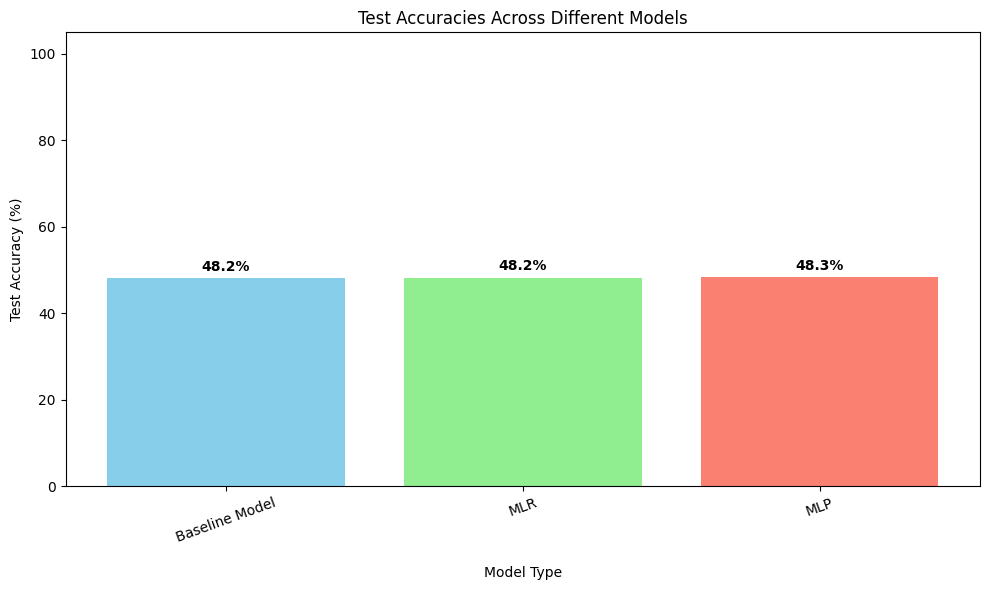

In [26]:
ploter = PlotGeneration()

ploter.display_test_accuracies(base_results['testing_accuracy'], MLR_results['testing_accuracy'], MLP_results['testing_accuracy'])

Let's see the learning curves and losses, for the different models indvidually.

Starting with Logistic Regression

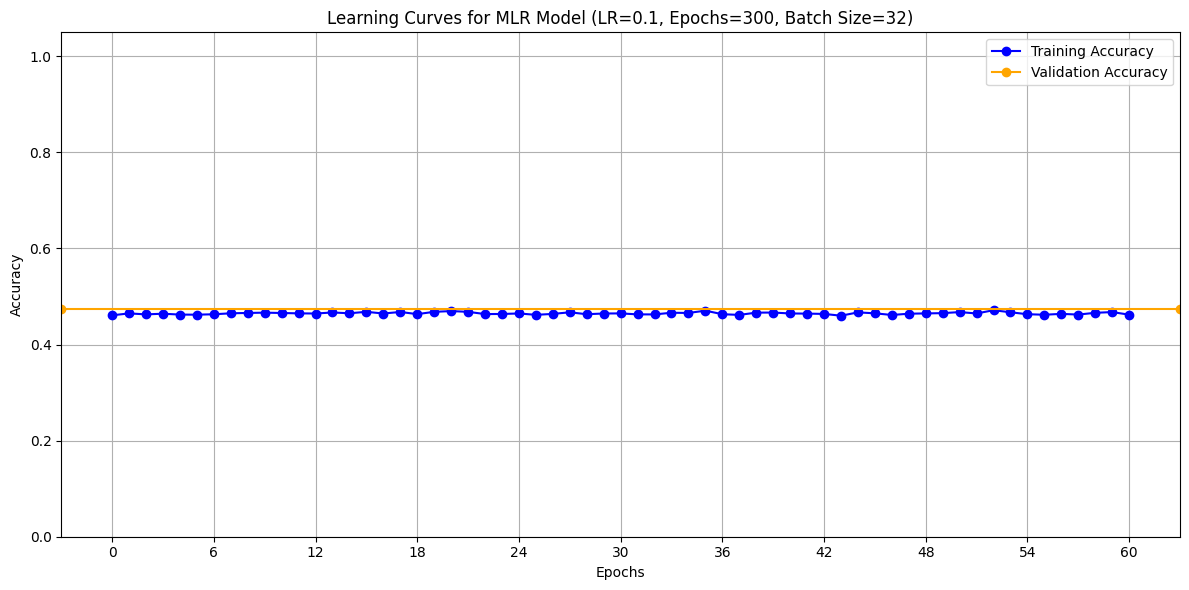

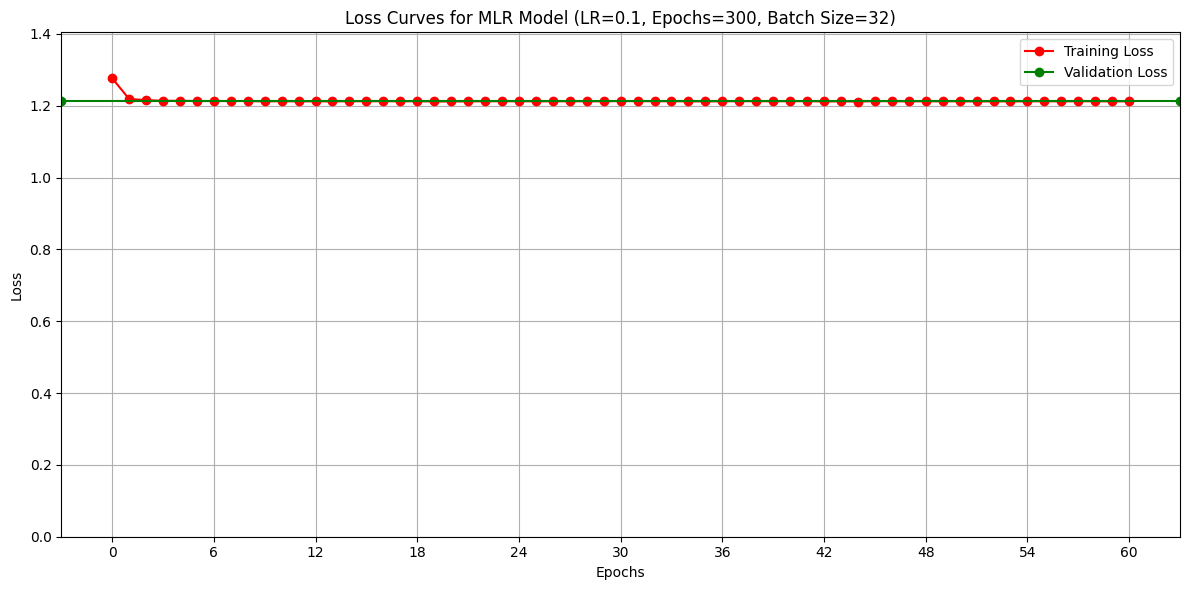

In [27]:
ploter.display_learning_curves(MLR_train_acc_history, MLR_best_configuration['validation_accuracy'], MLR_best_configuration, "MLR")
ploter.display_loss_curves(MLR_train_loss_history, MLR_best_configuration, "MLR")

The learning curves showcase that the model is achieving perfect generalization as tranining accuracies and validation accuracies align, while not overfitting nor underfitting.

The loss curves also indicate this optimal model capacity, as the training losses and validaion loss align. 

These show a highly robust classifier.

Now Let's do the same with MLP

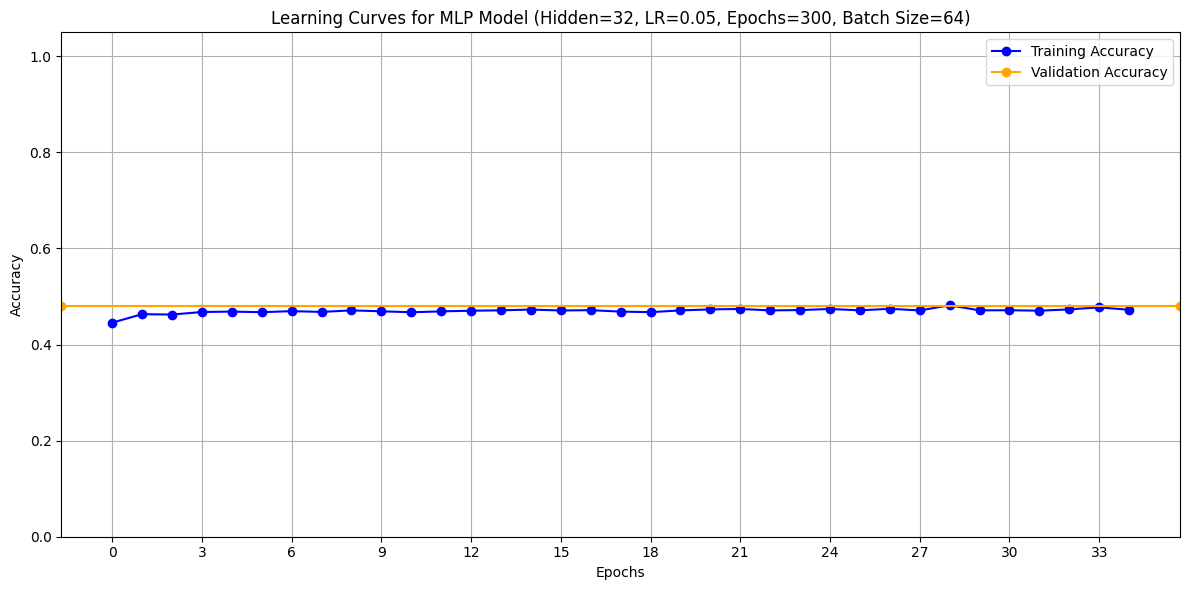

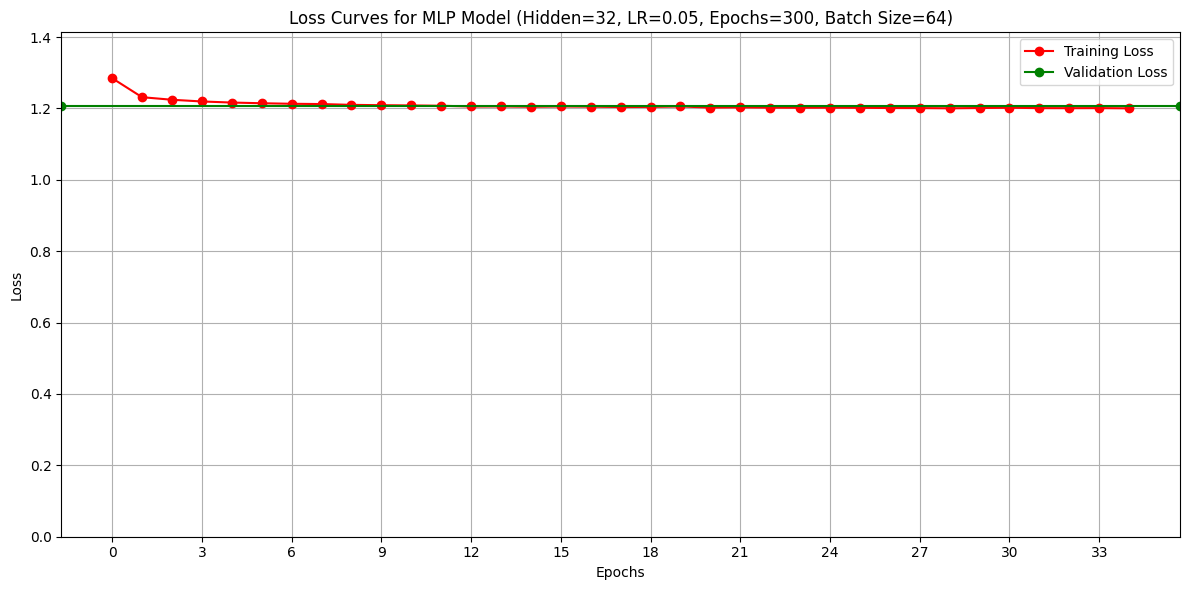

In [28]:
ploter.display_learning_curves(MLP_train_acc_history, MLP_best_configuration['validation_accuracy'], MLP_best_configuration, "MLP")
ploter.display_loss_curves(MLP_train_loss_history, MLP_best_configuration, "MLP")

Similar to Multinomial Logistic Regression, the learning curves showcase that the model is achieving perfect generalization as tranining accuracies and validation accuracies align, while not overfitting nor underfitting. Compared to MLR, it does have an initial misalignment, but rapidly matches the validation accuracy.

The loss curves also indicate this optimal model capacity, as the training losses and validaion loss align. 

These show a highly robust classifier.

### 8.2 Metric Analysis

Accuracy alone is misleading here because `COLLISION_TYPE` is imbalanced (a handful of categories dominate the dataset). We therefore compute a fuller set of metrics for both models' best configurations, all evaluated on the held-out `X_test_np` / `y_test_np` split that neither model trained or tuned on:

- Recall, Precision, and F1-score for `COLLISION_TYPE` (both macro-averaged and per class)
- Balanced accuracy (accounts for class imbalance, unlike plain accuracy)
- Average precision / PR-AUC (macro-averaged one-vs-rest)
- Confusion matrix for each model

First, rebuild each model's best configuration from its saved weights and generate predictions on the test set.

In [29]:
# Get test-set predictions from the best MLR model
logreg_probs = MLR_best_model.forward(X_test_np)
logreg_preds = np.argmax(logreg_probs, axis=1)

# Get test-set predictions from the best MLP model
mlp_probs = MLP_best_model.forward(X_test_np)
mlp_preds = np.argmax(mlp_probs, axis=1)

# Ground truth as class indices, and readable class names for COLLISION_TYPE
y_test_labels = np.argmax(y_test_np, axis=1)
class_names = [c.replace(f"{chosen_target}_", "") for c in y_columns]

Macro-averaged metrics let us compare the two models on equal footing across all seven collision types, instead of letting the majority classes dominate the score.

In [30]:
metrics_df = pd.DataFrame([
    summarize_metrics(y_test_labels, logreg_preds, logreg_probs, y_test_np, 'Logistic Regression'),
    summarize_metrics(y_test_labels, mlp_preds, mlp_probs, y_test_np, 'MLP (Neural Network)'),
]).set_index('Model')

metrics_df.round(4)

,Accuracy,Balanced Accuracy,Precision (macro),Recall (macro),F1-score (macro),PR-AUC (macro)
Model,,,,,,
Logistic Regression,0.4824,0.1607,0.1369,0.1607,0.1453,0.1896
MLP (Neural Network),0.4834,0.1610,0.1371,0.1610,0.1455,0.2009


Per-class breakdown, since the macro averages above can still hide how each model handles individual, less-frequent collision types.

In [31]:
logreg_report = pd.DataFrame(
    classification_report(y_test_labels, logreg_preds, target_names=class_names, output_dict=True, zero_division=0)
).T.round(3)

mlp_report = pd.DataFrame(
    classification_report(y_test_labels, mlp_preds, target_names=class_names, output_dict=True, zero_division=0)
).T.round(3)

print("Logistic Regression — per-class report")
display(logreg_report)

print("MLP (Neural Network) — per-class report")
display(mlp_report)

Logistic Regression — per-class report


,precision,recall,f1-score,support
Angle Impact,0.000,0.000,0.000,263.000
Head-On,0.000,0.000,0.000,7.000
Hit Object,0.000,0.000,0.000,103.000
Multiple,0.000,0.000,0.000,67.000
Rear-End,0.470,0.404,0.435,1123.000
Self-Accident,0.000,0.000,0.000,42.000
Side Swipe,0.488,0.720,0.582,1345.000
accuracy,0.482,0.482,0.482,0.482
macro avg,0.137,0.161,0.145,2950.000
weighted avg,0.402,0.482,0.431,2950.000


MLP (Neural Network) — per-class report


,precision,recall,f1-score,support
Angle Impact,0.000,0.000,0.000,263.000
Head-On,0.000,0.000,0.000,7.000
Hit Object,0.000,0.000,0.000,103.000
Multiple,0.000,0.000,0.000,67.000
Rear-End,0.469,0.403,0.434,1123.000
Self-Accident,0.000,0.000,0.000,42.000
Side Swipe,0.490,0.723,0.584,1345.000
accuracy,0.483,0.483,0.483,0.483
macro avg,0.137,0.161,0.145,2950.000
weighted avg,0.402,0.483,0.432,2950.000


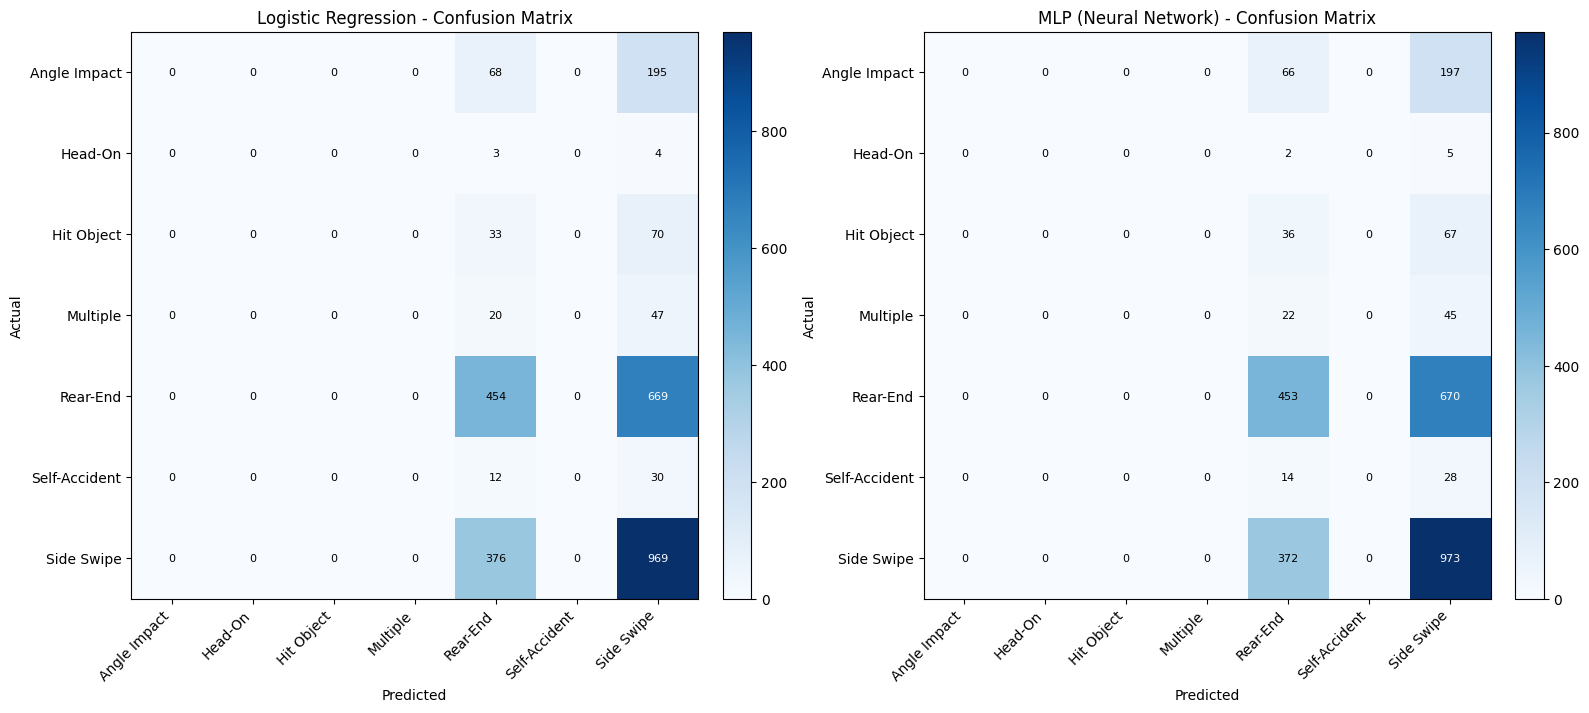

In [32]:
cm_logreg = confusion_matrix(y_test_labels, logreg_preds)
cm_mlp = confusion_matrix(y_test_labels, mlp_preds)

ploter.plot_confusion_matrices(cm_logreg, cm_mlp, class_names, 'Logistic Regression', 'MLP (Neural Network)')

### 8.3 Comparative Analysis

With both models evaluated on the same held-out test set, we can now compare them directly on the same set of metrics.

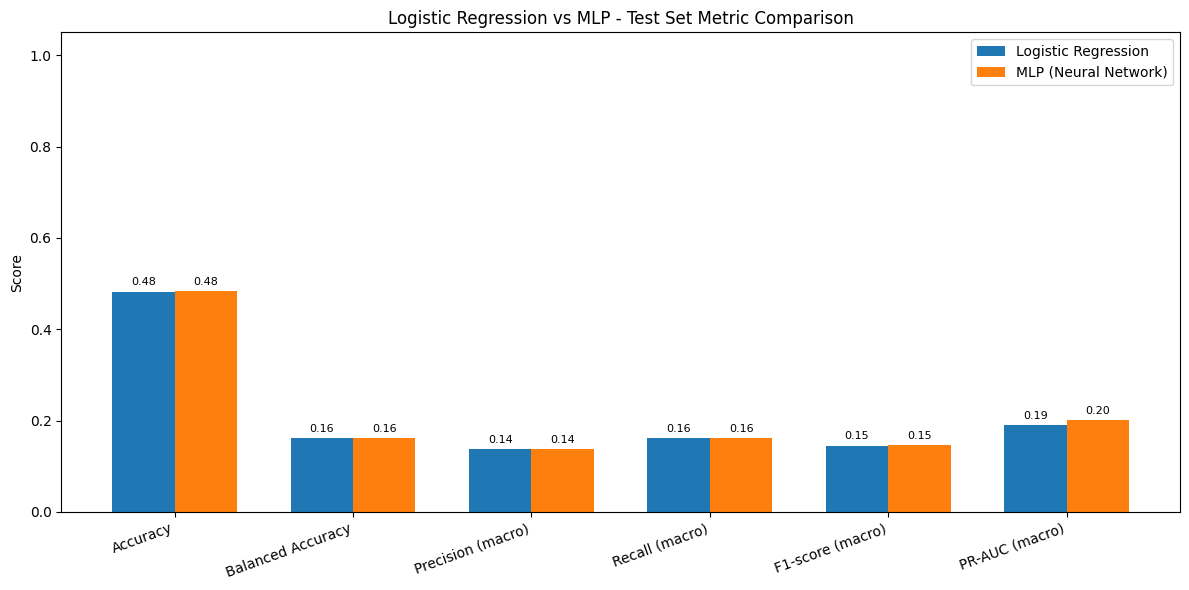

In [33]:
ploter.compare_metrics_bar(metrics_df)

### 8.4 Results Interpretation

**Test-set metrics** (held-out set of 2,950 rows, never used for training or hyperparameter tuning):

| Metric | Logistic Regression | MLP (Neural Network) |
|---|---|---|
| Accuracy | 48.24% | 48.34% |
| Balanced Accuracy | 16.07% | 16.10% |
| Precision (macro) | 0.1369 | 0.1371 |
| Recall (macro) | 0.1607 | 0.1610 |
| F1-score (macro) | 0.1453 | 0.1455 |
| PR-AUC (macro) | 0.1896 | 0.2009 |
| Mean 5-fold CV Accuracy | 47.42% (± 0.62%) | 48.00% (± 0.64%) |

Best configurations selected by 5-fold cross-validation: **MLR** — LR = 0.1, batch = 32, early stop at epoch 60 (val. acc. 47.84%); **MLP** — hidden = 32, LR = 0.05, batch = 64, early stop at epoch 34 (val. acc. 48.14%). Both were trained under a 300-epoch cap with patience = 20.

**Bottom line:** both models effectively collapse into a two-class classifier (*Side Swipe* vs. *Rear-End*), so the reassuring-looking ~48% accuracy is misleading; the macro-averaged metrics (~16% balanced accuracy, ~0.145 macro F1) are the honest picture, and the MLP's extra hidden layer buys essentially nothing over plain logistic regression on this feature set.

- **Class imbalance dominates both models' errors.** *Side Swipe* (1,345 rows, 45.6% of the test set) and *Rear-End* (1,123 rows, 38.1%) together account for 83.7% of all test rows, while the other five classes — *Angle Impact* (263), *Hit Object* (103), *Multiple* (67), *Self-Accident* (42), and *Head-On* (7) — share the remaining 16.3%.
- **Both models assign 0.000 precision, recall, and F1 to all five minority classes**: every one of the 2,950 test rows is placed into either *Side Swipe* or *Rear-End*, and neither model predicts *Angle Impact* even once despite it being the third-largest class at 263 rows. Both are therefore two-class classifiers dressed up as seven-class ones, which is why plain accuracy (~48%) looks far more respectable than the macro-averaged figures (macro F1 ≈ 0.145, balanced accuracy ≈ 16%).
- **Accuracy vs. macro/balanced metrics.** The ~32-point gap between raw accuracy (~48%) and balanced accuracy (~16%) is the clearest evidence of the imbalance problem: a model that always predicted *Side Swipe* would score 45.6% without learning anything at all, so the models buy only 2.6 points (LR) and 2.7 points (MLP) over that trivial baseline. Because neither model ever predicts the other five classes, macro recall collapses to just the two majority recalls divided by seven — (0.404 + 0.720)/7 for MLR and (0.403 + 0.723)/7 for the MLP — landing both barely above random guessing (1/7 ≈ 14.3%) across the full class set.
- **Logistic Regression vs. MLP — nearly identical decisions.** On this run the two models are, for practical purposes, the same classifier. Accuracy differs by 0.10 points — three test rows out of 2,950 — and the per-class reports are near-identical (*Rear-End* F1 0.435 vs. 0.434; *Side Swipe* F1 0.582 vs. 0.584). Macro precision, recall, and F1 all agree to within 0.0003. The 5-fold CV accuracies (47.42% vs. 48.00%) differ by 0.58 points, but with fold-to-fold spreads of ±0.62% and ±0.64% the two ranges overlap substantially, so that gap is not decisive either.
- **The one real difference — PR-AUC.** The only metric with a genuine gap is **PR-AUC (0.2009 vs. 0.1896, +0.0113 for the MLP)**, and the reason is instructive: PR-AUC is computed from the predicted *probabilities* rather than the arg-max label, so it can reward the MLP for ranking minority-class rows slightly higher even though the arg-max decision rule never actually selects them. The hidden layer is learning a marginally better-ordered probability surface that the final decision rule then throws away. Taken together, the non-linear model buys essentially nothing over the linear one here — the class imbalance and the limited feature set (`X`, `Y`, `HOUR_SIN`, `HOUR_COS`, `SEVERITY`) are the real bottleneck, not the choice between a linear and a non-linear architecture.
- **Next steps to improve both models**, worth trying and reporting on for the Error Analysis criterion:
  - Class weighting or resampling (e.g. oversampling *Head-On*/*Self-Accident* or undersampling *Side Swipe*) to force the loss to pay attention to minority classes.
  - Adjusting the decision rule away from plain arg-max (per-class thresholds or prior correction), since the MLP's higher PR-AUC suggests its probability ranking already contains minority-class signal that arg-max discards.
  - Collapsing the rarest classes (*Head-On*, *Multiple*) into a broader "Other" category if they remain unrecoverable.
  - Adding engineered features such as day-of-week, time-of-day bucket, or road segment/intersection ID, since the current five features appear insufficient to separate collision types beyond the two dominant ones.
  - Raising the epoch cap is *not* a promising lever — both models early-stopped at epochs 60 and 34, well short of the 300 allowed, so they had already converged.